In [1]:
!pip install xgboost shap category_encoders joblib seaborn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 7.4 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, VotingClassifier
from xgboost import XGBClassifier

import category_encoders as ce
import shap
import joblib


In [3]:
df = pd.read_csv("/content/loan_approval_dataset.csv")

df.columns = df.columns.str.strip()

df.head()


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


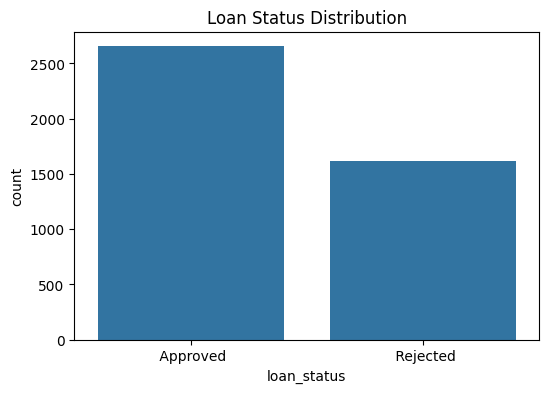

In [4]:
plt.figure(figsize=(6,4))

sns.countplot(x="loan_status", data=df)

plt.title("Loan Status Distribution")

plt.show()


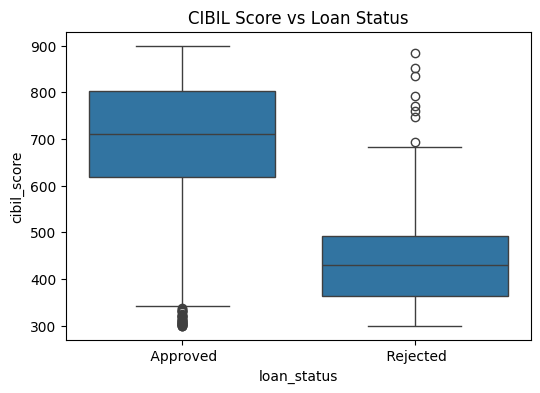

In [5]:
plt.figure(figsize=(6,4))

sns.boxplot(x="loan_status", y="cibil_score", data=df)

plt.title("CIBIL Score vs Loan Status")

plt.show()


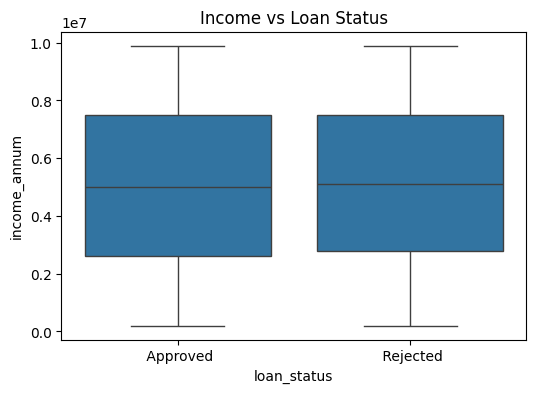

In [6]:
plt.figure(figsize=(6,4))

sns.boxplot(x="loan_status", y="income_annum", data=df)

plt.title("Income vs Loan Status")

plt.show()


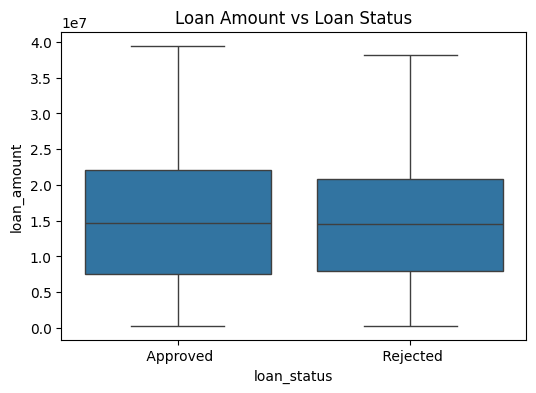

In [7]:
plt.figure(figsize=(6,4))

sns.boxplot(x="loan_status", y="loan_amount", data=df)

plt.title("Loan Amount vs Loan Status")

plt.show()


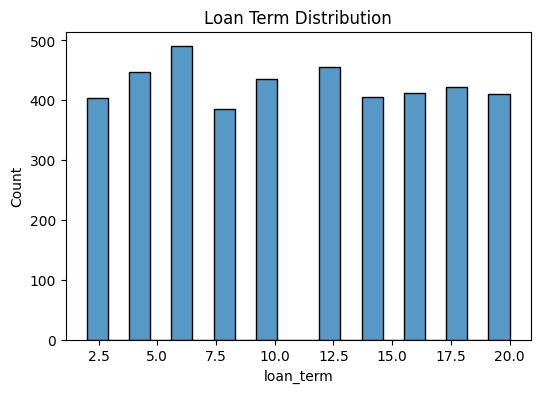

In [8]:
plt.figure(figsize=(6,4))

sns.histplot(df["loan_term"], bins=20)

plt.title("Loan Term Distribution")

plt.show()


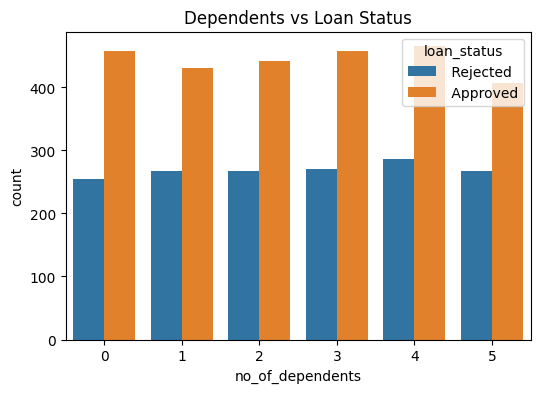

In [9]:
plt.figure(figsize=(6,4))

sns.countplot(x="no_of_dependents", hue="loan_status", data=df)

plt.title("Dependents vs Loan Status")

plt.show()


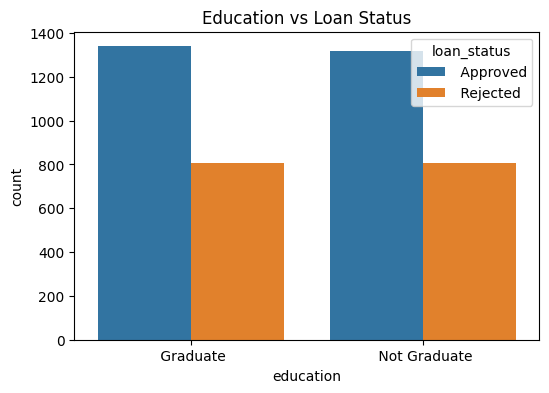

In [10]:
plt.figure(figsize=(6,4))

sns.countplot(x="education", hue="loan_status", data=df)

plt.title("Education vs Loan Status")

plt.show()


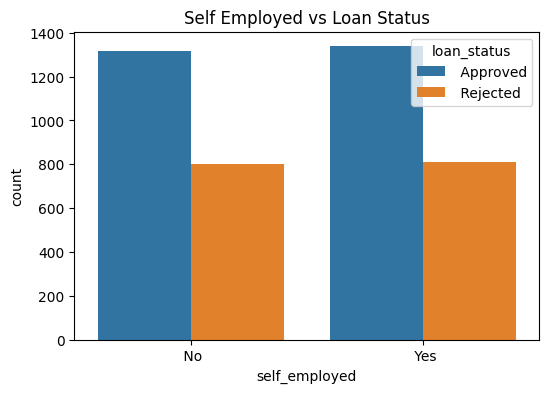

In [11]:
plt.figure(figsize=(6,4))

sns.countplot(x="self_employed", hue="loan_status", data=df)

plt.title("Self Employed vs Loan Status")

plt.show()


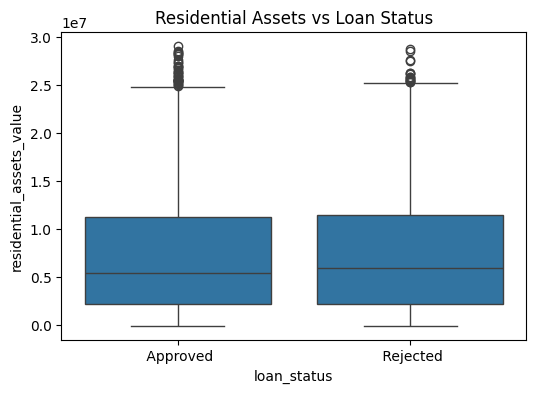

In [12]:
plt.figure(figsize=(6,4))

sns.boxplot(x="loan_status",
            y="residential_assets_value",
            data=df)

plt.title("Residential Assets vs Loan Status")

plt.show()


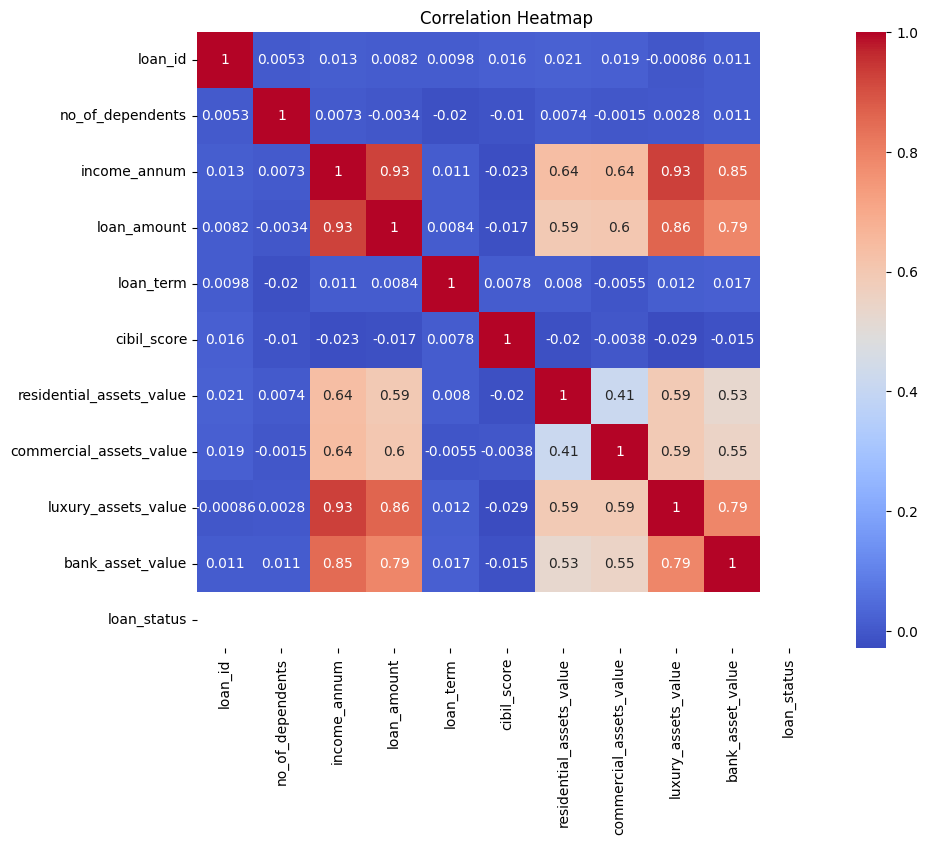

In [13]:
df_encoded = df.copy()

df_encoded["loan_status"] = df_encoded["loan_status"].map({
"Approved":0,
"Rejected":1
})

df_encoded = df_encoded.select_dtypes(include=['int64','float64'])
plt.figure(figsize=(10,8))

sns.heatmap(df_encoded.corr(),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()


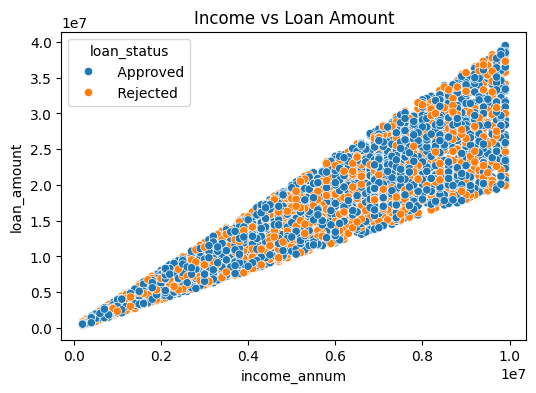

In [14]:
plt.figure(figsize=(6,4))

sns.scatterplot(x="income_annum",
                y="loan_amount",
                hue="loan_status",
                data=df)

plt.title("Income vs Loan Amount")

plt.show()


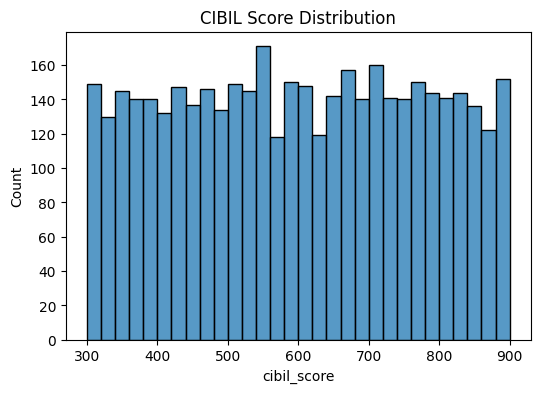

In [15]:
plt.figure(figsize=(6,4))

sns.histplot(df["cibil_score"], bins=30)

plt.title("CIBIL Score Distribution")

plt.show()


In [16]:
le = LabelEncoder()

df['loan_status'] = le.fit_transform(df['loan_status'])

# Approved = 0
# Rejected = 1


In [17]:
encoder = ce.WOEEncoder()

df[['education','self_employed']] = encoder.fit_transform(

df[['education','self_employed']],
df['loan_status']

)


In [18]:
X = df[[

'no_of_dependents',
'education',
'self_employed',
'income_annum',
'loan_amount',
'loan_term',
'cibil_score',
'residential_assets_value',
'commercial_assets_value',
'luxury_assets_value',
'bank_asset_value'

]]

y = df['loan_status']


In [19]:
X_train, X_test, y_train, y_test = train_test_split(

X, y,
test_size=0.2,
random_state=42,
stratify=y

)


In [20]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)


In [21]:
rf = RandomForestClassifier(n_estimators=300)

rf.fit(X_train, y_train)


RandomForestClassifier(n_estimators=300)

In [22]:
ada = AdaBoostClassifier(n_estimators=300)

ada.fit(X_train, y_train)


AdaBoostClassifier(n_estimators=300)

In [23]:
xgb = XGBClassifier(n_estimators=300)

xgb.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

In [24]:
ensemble = VotingClassifier(

estimators=[

('rf', rf),
('ada', ada),
('xgb', xgb)

],

voting='soft'

)

ensemble.fit(X_train, y_train)


VotingClassifier(estimators=[('rf', RandomForestClassifier(n_estimators=300)),
                             ('ada', AdaBoostClassifier(n_estimators=300)),
                             ('xgb',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric=None,
                                            feature_types=N...
                                            feature_weights=None, gamma=None,
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_rate=None, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=None,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=300, n_jobs=None,
                                            num_parallel_tree=None, ...))],
                 voting='soft')

In [25]:
y_pred = ensemble.predict(X_test)


In [26]:
print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.9812646370023419


In [27]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.98      0.99      0.99       531
           1       0.98      0.97      0.97       323

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



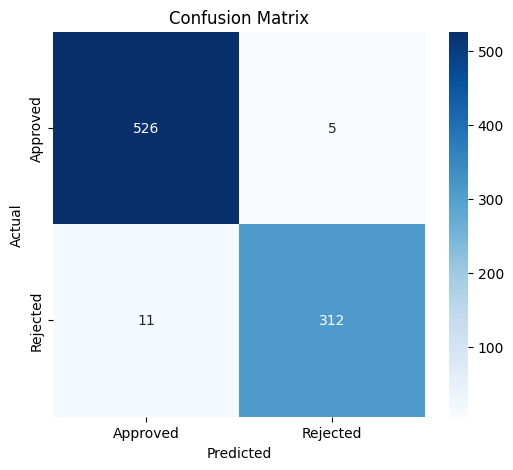

In [28]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Approved','Rejected'],
            yticklabels=['Approved','Rejected'])

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()


In [29]:
explainer = shap.Explainer(xgb)

shap_values = explainer(X_test)


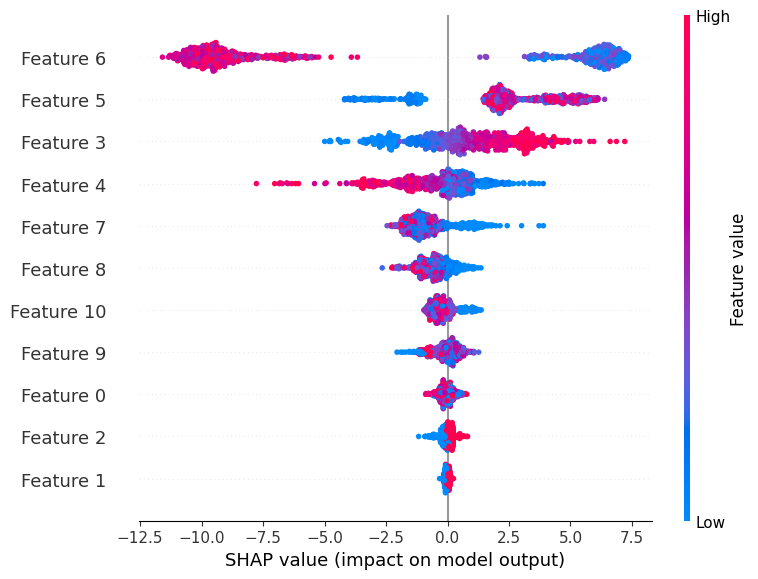

In [30]:
shap.summary_plot(shap_values, X_test)


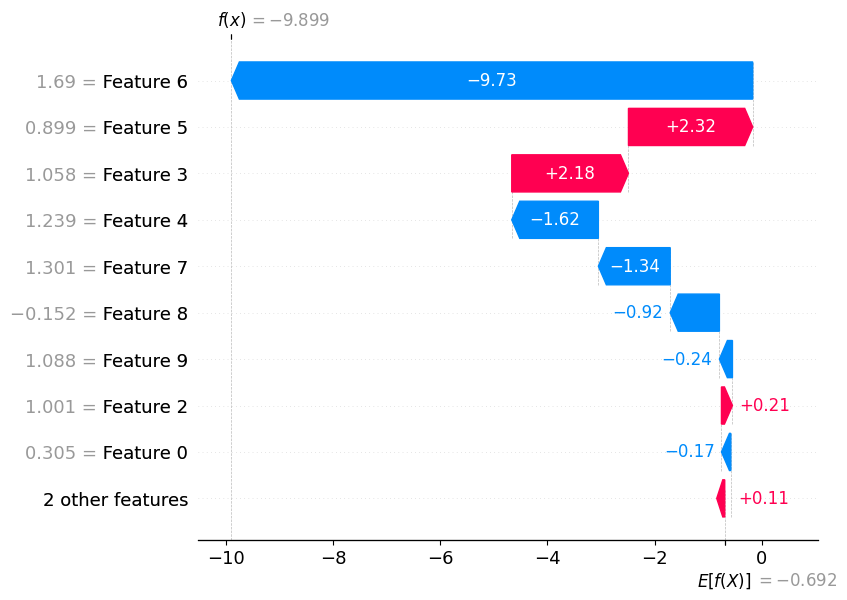

In [31]:
shap.plots.waterfall(shap_values[0])


In [32]:
joblib.dump(ensemble,"loan_model.pkl")

joblib.dump(scaler,"scaler.pkl")


['scaler.pkl']

In [33]:
from google.colab import files

files.download("loan_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [34]:
# ================================
# LOAN ELIGIBILITY & ADVISORY SYSTEM
# WITH SHAP EXPLAINABLE AI
# SINGLE CELL GRADIO APP
# ================================

import gradio as gr
import joblib
import pandas as pd
import numpy as np
import shap


# ================================
# LOAD MODEL AND SCALER
# ================================

model = joblib.load("loan_model.pkl")
scaler = joblib.load("scaler.pkl")

# Use XGBoost part for SHAP
xgb_model = model.estimators_[2]

explainer = shap.Explainer(xgb_model)


# ================================
# ADVISORY FUNCTIONS
# ================================

def calculate_interest(cibil):

    return max(1, 6 + (750 - cibil)/100)



def calculate_emi(loan_amount, rate, term):

    if rate <= 0:
        return 0

    R = rate/(12*100)

    N = term*12

    if (1+R)**N - 1 == 0:
        return 0

    emi = (loan_amount*R*(1+R)**N)/((1+R)**N-1)

    return emi



def calculate_dti(emi, income):

    if income <= 0:
        return 0

    return emi/(income/12)



def max_loan(income, rate, term):

    if income <= 0:
        return 0

    max_emi = income/12 * 0.4

    R = rate/(12*100)

    N = term*12

    return max_emi*((1+R)**N -1)/(R*(1+R)**N)



# ================================
# PREDICTION FUNCTION
# ================================

def predict_loan(

dependents,
education,
self_employed,
income,
loan_amount,
loan_term,
cibil,
res_assets,
com_assets,
lux_assets,
bank_assets

):

    # Encode categorical

    education_val = 1 if education=="Graduate" else 0

    self_val = 1 if self_employed=="Yes" else 0


    columns = [

    'no_of_dependents',
    'education',
    'self_employed',
    'income_annum',
    'loan_amount',
    'loan_term',
    'cibil_score',
    'residential_assets_value',
    'commercial_assets_value',
    'luxury_assets_value',
    'bank_asset_value'

    ]


    X = pd.DataFrame([[

    dependents,
    education_val,
    self_val,
    income,
    loan_amount,
    loan_term,
    cibil,
    res_assets,
    com_assets,
    lux_assets,
    bank_assets

    ]], columns=columns)


    # Scale input

    X_scaled = scaler.transform(X)


    # Prediction

    prediction = model.predict(X_scaled)[0]

    result = "Approved" if prediction==0 else "Rejected"


    # Advisory Calculations

    rate = calculate_interest(cibil)

    emi = calculate_emi(loan_amount, rate, loan_term)

    dti = calculate_dti(emi, income)

    maxloan = max_loan(income, rate, loan_term)


    advice = ""


    if cibil < 700:

        advice += "• Improve CIBIL score\n"


    if loan_amount > maxloan:

        advice += "• Loan exceeds eligibility\n"


    if dti > 0.4:

        advice += "• High EMI burden\n"


    if cibil >= 750:

        advice += "• Eligible for low-interest loans\n"


    # ================================
    # SHAP EXPLANATION
    # ================================

    shap_values = explainer(X_scaled)


    shap_reason = ""


    for i, val in enumerate(shap_values.values[0]):

        feature = columns[i]

        if val > 0:

            shap_reason += f"• {feature} contributed to REJECTION\n"

        else:

            shap_reason += f"• {feature} contributed to APPROVAL\n"



    return (

    result,
    round(rate,2),
    round(emi,2),
    round(dti,2),
    round(maxloan,2),
    advice,
    shap_reason

    )



# ================================
# GRADIO INTERFACE
# ================================

interface = gr.Interface(

fn=predict_loan,

inputs=[

gr.Number(label="Number of Dependents"),

gr.Dropdown(["Graduate","Not Graduate"], label="Education"),

gr.Dropdown(["Yes","No"], label="Self Employed"),

gr.Number(label="Annual Income"),

gr.Number(label="Loan Amount"),

gr.Number(label="Loan Term (Years)"),

gr.Number(label="CIBIL Score"),

gr.Number(label="Residential Assets Value"),

gr.Number(label="Commercial Assets Value"),

gr.Number(label="Luxury Assets Value"),

gr.Number(label="Bank Assets Value")

],

outputs=[

gr.Text(label="Loan Status"),

gr.Number(label="Interest Rate (%)"),

gr.Number(label="EMI"),

gr.Number(label="DTI"),

gr.Number(label="Maximum Eligible Loan"),

gr.Text(label="Advisory"),

gr.Text(label="SHAP Explanation (Reason for Decision)")

],

title="Loan Eligibility & Advisory System using Explainable AI",

description="Predict loan approval and understand the reason using SHAP"

)


interface.launch(debug=True)


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://7039a31e26dfe52e7d.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://7039a31e26dfe52e7d.gradio.live


In [35]:
# =====================================================
# FINAL LOAN ELIGIBILITY & ADVISORY SYSTEM
# WITH SHAP MAIN REASONS ONLY
# =====================================================

import gradio as gr
import joblib
import pandas as pd
import numpy as np
import shap


# =====================================================
# LOAD MODEL AND SCALER
# =====================================================

model = joblib.load("loan_model.pkl")
scaler = joblib.load("scaler.pkl")

# Use XGBoost part of ensemble for SHAP
xgb_model = model.estimators_[2]

explainer = shap.Explainer(xgb_model)


# =====================================================
# ADVISORY FUNCTIONS
# =====================================================

def calculate_interest(cibil):

    return max(1, 6 + (750 - cibil)/100)



def calculate_emi(loan_amount, rate, term):

    if rate <= 0:
        return 0

    R = rate/(12*100)

    N = term*12

    if (1+R)**N - 1 == 0:
        return 0

    return (loan_amount*R*(1+R)**N)/((1+R)**N-1)



def calculate_dti(emi, income):

    if income <= 0:
        return 0

    return emi/(income/12)



def max_loan(income, rate, term):

    if income <= 0:
        return 0

    max_emi = income/12 * 0.4

    R = rate/(12*100)

    N = term*12

    return max_emi*((1+R)**N -1)/(R*(1+R)**N)



# =====================================================
# MAIN PREDICTION FUNCTION
# =====================================================

def predict_loan(

dependents,
education,
self_employed,
income,
loan_amount,
loan_term,
cibil,
res_assets,
com_assets,
lux_assets,
bank_assets

):

    # Encode categorical

    education_val = 1 if education=="Graduate" else 0

    self_val = 1 if self_employed=="Yes" else 0


    columns = [

    'no_of_dependents',
    'education',
    'self_employed',
    'income_annum',
    'loan_amount',
    'loan_term',
    'cibil_score',
    'residential_assets_value',
    'commercial_assets_value',
    'luxury_assets_value',
    'bank_asset_value'

    ]


    X = pd.DataFrame([[

    dependents,
    education_val,
    self_val,
    income,
    loan_amount,
    loan_term,
    cibil,
    res_assets,
    com_assets,
    lux_assets,
    bank_assets

    ]], columns=columns)


    # Scale

    X_scaled = scaler.transform(X)


    # Predict

    prediction = model.predict(X_scaled)[0]

    result = "Approved" if prediction==0 else "Rejected"


    # =====================================================
    # ADVISORY CALCULATIONS
    # =====================================================

    rate = calculate_interest(cibil)

    emi = calculate_emi(loan_amount, rate, loan_term)

    dti = calculate_dti(emi, income)

    maxloan = max_loan(income, rate, loan_term)


    advice = ""


    if cibil < 700:

        advice += "• Improve CIBIL score\n"


    if loan_amount > maxloan:

        advice += "• Loan exceeds eligibility limit\n"


    if dti > 0.4:

        advice += "• High EMI burden\n"


    if cibil >= 750:

        advice += "• Eligible for low-interest loans\n"



    # =====================================================
    # SHAP MAIN REASONS ONLY
    # =====================================================

    shap_values = explainer(X_scaled)

    values = shap_values.values[0]

    feature_importance = list(zip(columns, values))

    feature_importance.sort(key=lambda x: abs(x[1]), reverse=True)


    main_reasons = ""


    for feature, val in feature_importance[:3]:

        if val > 0:

            main_reasons += f"• {feature} was a major reason for REJECTION\n"

        else:

            main_reasons += f"• {feature} supported APPROVAL\n"



    return (

    result,
    round(rate,2),
    round(emi,2),
    round(dti,2),
    round(maxloan,2),
    advice,
    main_reasons

    )



# =====================================================
# GRADIO INTERFACE
# =====================================================

interface = gr.Interface(

fn=predict_loan,

inputs=[

gr.Number(label="Number of Dependents"),

gr.Dropdown(["Graduate","Not Graduate"], label="Education"),

gr.Dropdown(["Yes","No"], label="Self Employed"),

gr.Number(label="Annual Income"),

gr.Number(label="Loan Amount"),

gr.Number(label="Loan Term (Years)"),

gr.Number(label="CIBIL Score"),

gr.Number(label="Residential Assets Value"),

gr.Number(label="Commercial Assets Value"),

gr.Number(label="Luxury Assets Value"),

gr.Number(label="Bank Assets Value")

],

outputs=[

gr.Text(label="Loan Status"),

gr.Number(label="Interest Rate (%)"),

gr.Number(label="EMI"),

gr.Number(label="DTI"),

gr.Number(label="Maximum Eligible Loan"),

gr.Text(label="Advisory"),

gr.Text(label="Main Reasons (SHAP Explanation)")

],

title="Loan Eligibility & Advisory System with Explainable AI",

description="Predict loan approval and see main reasons using SHAP"

)


interface.launch(debug=True)


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://e8ba5d1f82410d42aa.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://e8ba5d1f82410d42aa.gradio.live
